#### intro

In [1]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str
##
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}
##
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    
    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state'] 
    
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"
##


In [2]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

#here we can see added node1,2,3 to build and then to connect there is the logic where we set start to node 1 and then decide the branch

c:\Users\Nishad_Khade\OneDrive - Dell Technologies\Desktop\UI_POC\final_env\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


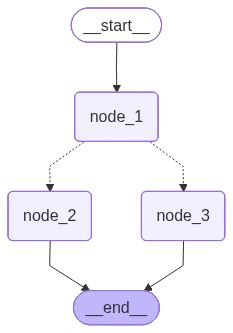

In [ ]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"graph_state" : "Hi, this is Lance."})

---Node 1---
---Node 3---
{'graph_state': 'Hi, this is Lance. I am sad!'}


#### first graph and langfuse setup
get email, ask llm to classify as ham or spam, if ham then write a reply, if spam then delete

In [3]:
import os
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

class EmailState(TypedDict): #info that need to be persisted and shared through

    email: Dict[str, Any]  # Contains subject, sender, body, etc.
    email_category: Optional[str]    # Category of the email (inquiry, complaint, etc.)
    spam_reason: Optional[str] # Reason why the email was marked as spam
    is_spam: Optional[bool]
    email_draft: Optional[str]

    messages: List[Dict[str, Any]]  # Track conversation with LLM for analysis

c:\Users\Nishad_Khade\OneDrive - Dell Technologies\Desktop\UI_POC\final_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Initialize our LLM

from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import os
from dotenv import load_dotenv
load_dotenv("./.env")

base_llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-Coder-32B-Instruct", #mistralai/Mistral-7B-Instruct-v0.2
    max_new_tokens=512,
    temperature=0.7,
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

chat_llm = ChatHuggingFace(llm=base_llm)
# here we need to wrap it in a chat abstraction because this model ka provider- the task is conversational, but under the hood lc hf endpoint class is fixed to the text generation task, but the provider doesnt give it so we will get error if we invoke as it is, so we wrap it in a chat abstraction, or we can use a model where the provider gives text-gen


In [9]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

# 1. Define your tool
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers together."""
    return a * b

llm_with_tools = chat_llm.bind_tools([multiply])

result = llm_with_tools.invoke([HumanMessage(content="What is 3 times 12?")])
print(result.tool_calls)

#so it depends on the llm and provider if they support tool binding

BadRequestError: (Request ID: Root=1-6a2418ca-64f02c1d16fc4cdc37783f0f;17260eb2-e5b8-4948-9191-58a9b4befa56)

Bad request:
{'code': '422', 'error_type': 'UNSUPPORTED_OPENAI_PARAMS', 'message': 'The following parameters are not supported for this model: tools', 'param': 'tools'}

In [ ]:
resp = chat_llm.invoke([HumanMessage(content="What is machine learning?")])
print(resp.content)

In [ ]:
import base64
from typing import List, TypedDict, Annotated, Optional
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

class AgentState(TypedDict):
    input_file: Optional[str]  # Contains file path (PDF/PNG) or any input
    messages: Annotated[list[AnyMessage], add_messages]

#bind few tools to llm
vision_llm = ChatOpenAI(model="gpt-4o", api_key="key-here")
def extract_text(img_path: str) -> str:
    """
    Extract text from an image file using a multimodal model.
    
    Master Wayne often leaves notes with his training regimen or meal plans.
    This allows me to properly analyze the contents.
    """
    all_text = ""
    try:
        # Read image and encode as base64
        with open(img_path, "rb") as image_file:
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        # Prepare the prompt including the base64 image data
        message = [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": (
                            "Extract all the text from this image. "
                            "Return only the extracted text, no explanations."
                        ),
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        },
                    },
                ]
            )
        ]

        # Call the vision-capable model
        response = vision_llm.invoke(message)

        # Append extracted text
        all_text += response.content + "\n\n"

        return all_text.strip()
    except Exception as e:
        # A butler should handle errors gracefully
        error_msg = f"Error extracting text: {str(e)}"
        print(error_msg)
        return ""
def divide(a: int, b: int) -> float:
    """Divide a and b - for Master Wayne's occasional calculations."""
    return a / b

# Equip with tools
tools = [
    divide,
    extract_text
]

llm = ChatOpenAI(model="gpt-4o",api_key="key-here")
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)
#now llm is ready to be use in the assistant node of the graph

In [8]:
#node functions
def read_email(state: EmailState):
    """Alfred reads and logs the incoming email"""
    email = state["email"]
    
    # Here we might do some initial preprocessing
    print(f"Alfred is processing an email from {email['sender']} with subject: {email['subject']}")
    
    # No state changes needed here
    return {}

def classify_email(state: EmailState):
    """Alfred uses an LLM to determine if the email is spam or legitimate"""
    email = state["email"]
    
    # Prepare our prompt for the LLM
    prompt = f"""
    Analyze this email and determine if it is spam or legitimate.
    
    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}
    
    First, determine if this email is spam. If it is spam, explain why
    If it is legitimate, categorize it (inquiry, complaint, thank you, etc.).
    """
    
    # Call the LLM

    system_prompt = """You are Alfred the butler. You are a helpful assistant.
    
    When analyzing emails, you must respond in the following strict format:
    status: <SPAM or NOT SPAM>
    reason: <your reasoning>
    category: <inquiry, complaint, thank you, request, information, or N/A if spam>
    """

    messages = [SystemMessage(content=system_prompt), HumanMessage(content=prompt)]
    

    response = chat_llm.invoke(messages)
    
    # Simple logic to parse the response (in a real app, you'd want more robust parsing)
    response_text = response.content.lower()
    is_spam = "spam" in response_text and "not spam" not in response_text
    
    # Extract a reason if it's spam
    spam_reason = None
    if is_spam and "reason:" in response_text:
        spam_reason = response_text.split("reason:")[1].strip()
    
    # Determine category if legitimate
    email_category = None
    if not is_spam:
        categories = ["inquiry", "complaint", "thank you", "request", "information"]
        for category in categories:
            if category in response_text:
                email_category = category
                break
    
    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    
    # Return state updates
    return {
        "is_spam": is_spam,
        "spam_reason": spam_reason,
        "email_category": email_category,
        "messages": new_messages
    }

def handle_spam(state: EmailState):
    """Alfred discards spam email with a note"""
    print(f"Alfred has marked the email as spam. Reason: {state['spam_reason']}")
    print("The email has been moved to the spam folder.")
    
    # We're done processing this email
    return {}

def draft_response(state: EmailState):
    """Alfred drafts a preliminary response for legitimate emails"""
    email = state["email"]
    category = state["email_category"] or "general"
    
    # Prepare our prompt for the LLM
    prompt = f"""
    As Alfred the butler, draft a polite preliminary response to this email.
    
    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}
    
    This email has been categorized as: {category}
    
    Draft a brief, professional response that Mr. Hugg can review and personalize before sending.
    """
    
    # Call the LLM
    messages = [HumanMessage(content=prompt)]
    response = chat_llm.invoke(messages)
    
    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    
    # Return state updates
    return {
        "email_draft": response.content,
        "messages": new_messages
    }

def notify_mr_hugg(state: EmailState):
    """Alfred notifies Mr. Hugg about the email and presents the draft response"""
    email = state["email"]
    
    print("\n" + "="*50)
    print(f"Sir, you've received an email from {email['sender']}.")
    print(f"Subject: {email['subject']}")
    print(f"Category: {state['email_category']}")
    print("\nI've prepared a draft response for your review:")
    print("-"*50)
    print(state["email_draft"])
    print("="*50 + "\n")
    
    # We're done processing this email
    return {}

In [9]:
# edge to route based on spam or not
def route_email(state: EmailState) -> str:
    """Determine the next step based on spam classification"""
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

In [10]:
# Create the graph
email_graph = StateGraph(EmailState)

# Add nodes
email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("draft_response", draft_response)
email_graph.add_node("notify_mr_hugg", notify_mr_hugg)

# Start the edges
email_graph.add_edge(START, "read_email")
# Add edges - defining the flow
email_graph.add_edge("read_email", "classify_email")

# Add conditional branching from classify_email
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "spam": "handle_spam",
        "legitimate": "draft_response"
    }
)
#lets say we need to route, here basically after classify email, route email is the routing function, if response from that function is spam then we take the handle span path after classify, if its legitimate we take the draft response step, using this add conditional edge statement we decidied the flow, we couldve also directly returned the exact node name so this mapping wouldnt have been necessary

# Add the final edges
email_graph.add_edge("handle_spam", END)
email_graph.add_edge("draft_response", "notify_mr_hugg")
email_graph.add_edge("notify_mr_hugg", END)

# Compile the graph
compiled_graph = email_graph.compile()

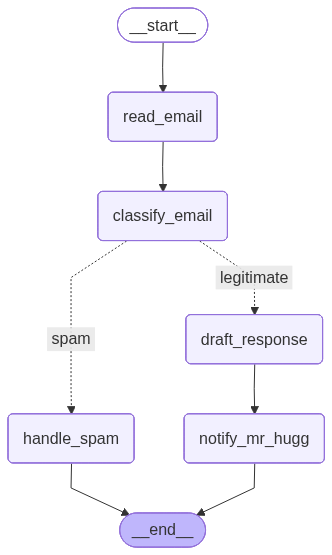

In [11]:
# View
display(Image(compiled_graph.get_graph().draw_mermaid_png()))

In [12]:
# Example legitimate email
legitimate_email = {
    "sender": "john.smith@gmail.com",
    "subject": "Question about your services",
    "body": "Dear Mr. Hugg, I was referred to you by a colleague and I'm interested in learning more about your consulting services. Could we schedule a call next week? Best regards, John Smith"
}

# Example spam email
spam_email = {
    "sender": "winner@lottery-intl.com",
    "subject": "YOU HAVE WON $5,000,000!!!",
    "body": "CONGRATULATIONS! You have been selected as the winner of our international lottery! To claim your $5,000,000 prize, please send us your bank details and a processing fee of $100."
}

# Process the legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})

# Process the spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing legitimate email...
Alfred is processing an email from john.smith@gmail.com with subject: Question about your services

Sir, you've received an email from john.smith@gmail.com.
Subject: Question about your services
Category: inquiry

I've prepared a draft response for your review:
--------------------------------------------------
Subject: Re: Question about your services

Dear Mr. Smith,

Thank you for reaching out and expressing your interest in Mr. Hugg's consulting services. It is wonderful to hear from you following the referral from your colleague.

Mr. Hugg will be delighted to discuss his services with you further. To accommodate your schedule, could you please provide a few possible times next week when you might be available for a call?

We look forward to hearing from you.

Best regards,

Alfred the Butler  
[Your Company Name]  
[Your Contact Information]


Processing spam email...
Alfred is processing an email from winner@lottery-intl.com with subject: YOU HAVE

In [13]:
legitimate_result

{'email': {'sender': 'john.smith@gmail.com',
  'subject': 'Question about your services',
  'body': "Dear Mr. Hugg, I was referred to you by a colleague and I'm interested in learning more about your consulting services. Could we schedule a call next week? Best regards, John Smith"},
 'email_category': 'inquiry',
 'spam_reason': None,
 'is_spam': False,
 'email_draft': "Subject: Re: Question about your services\n\nDear Mr. Smith,\n\nThank you for reaching out and expressing your interest in Mr. Hugg's consulting services. It is wonderful to hear from you following the referral from your colleague.\n\nMr. Hugg will be delighted to discuss his services with you further. To accommodate your schedule, could you please provide a few possible times next week when you might be available for a call?\n\nWe look forward to hearing from you.\n\nBest regards,\n\nAlfred the Butler  \n[Your Company Name]  \n[Your Contact Information]",
 'messages': [{'role': 'user',
   'content': "\n    Analyze this

In [14]:
spam_result

{'email': {'sender': 'winner@lottery-intl.com',
  'subject': 'YOU HAVE WON $5,000,000!!!',
  'body': 'CONGRATULATIONS! You have been selected as the winner of our international lottery! To claim your $5,000,000 prize, please send us your bank details and a processing fee of $100.'},
 'email_category': None,
 'spam_reason': 'the email appears to be a common lottery scam where unsolicited recipients are notified of winnings they did not enter to win. it asks for sensitive personal information such as bank details, which is a red flag indicating fraudulent activity. additionally, the request for a processing fee before claiming the prize is typical of these scams.  \ncategory: n/a',
 'is_spam': True,
 'email_draft': None,
 'messages': [{'role': 'user',
   'content': '\n    Analyze this email and determine if it is spam or legitimate.\n\n    Email:\n    From: winner@lottery-intl.com\n    Subject: YOU HAVE WON $5,000,000!!!\n    Body: CONGRATULATIONS! You have been selected as the winner of

In [30]:
import os
from dotenv import load_dotenv
load_dotenv()

LANGFUSE_SECRET_KEY=os.getenv("LANGFUSE_SECRET_KEY")
LANGFUSE_PUBLIC_KEY=os.getenv("LANGFUSE_PUBLIC_KEY")
LANGFUSE_HOST=os.getenv("LANGFUSE_HOST")


os.environ["LANGFUSE_PUBLIC_KEY"] = LANGFUSE_PUBLIC_KEY
os.environ["LANGFUSE_SECRET_KEY"] = LANGFUSE_SECRET_KEY
os.environ["LANGFUSE_HOST"] = LANGFUSE_HOST


In [ ]:
from langfuse.langchain import CallbackHandler

# Initialize Langfuse CallbackHandler for LangGraph/Langchain (tracing)
langfuse_handler = CallbackHandler()

# Process legitimate email
legitimate_result = compiled_graph.invoke(
    input={"email": legitimate_email, "is_spam": None, "spam_reason": None, "email_category": None, "draft_response": None, "messages": []},
    config={"callbacks": [langfuse_handler]}
)

langfuse_handler.flush()

#### document analysis graph - ReAct framework agent
lets say we have to make an assistant with has multiple tools and the assistant will loop over steps(react reasoning act observe) until it figures out the task and then ends, typically what we do in agentic systems.

But here we dont have to worry much about the conversation handling and all that like parsing llm output executing the tools sending its output and stuff all is taken care of

In [ ]:
# using function calling here, to bind tools to llm (augmenting the llm), the graph will be one node assistant and a node of all tools where there is a cycle between the assistant node and the tools node (the tools node is a special one given by langgraph)

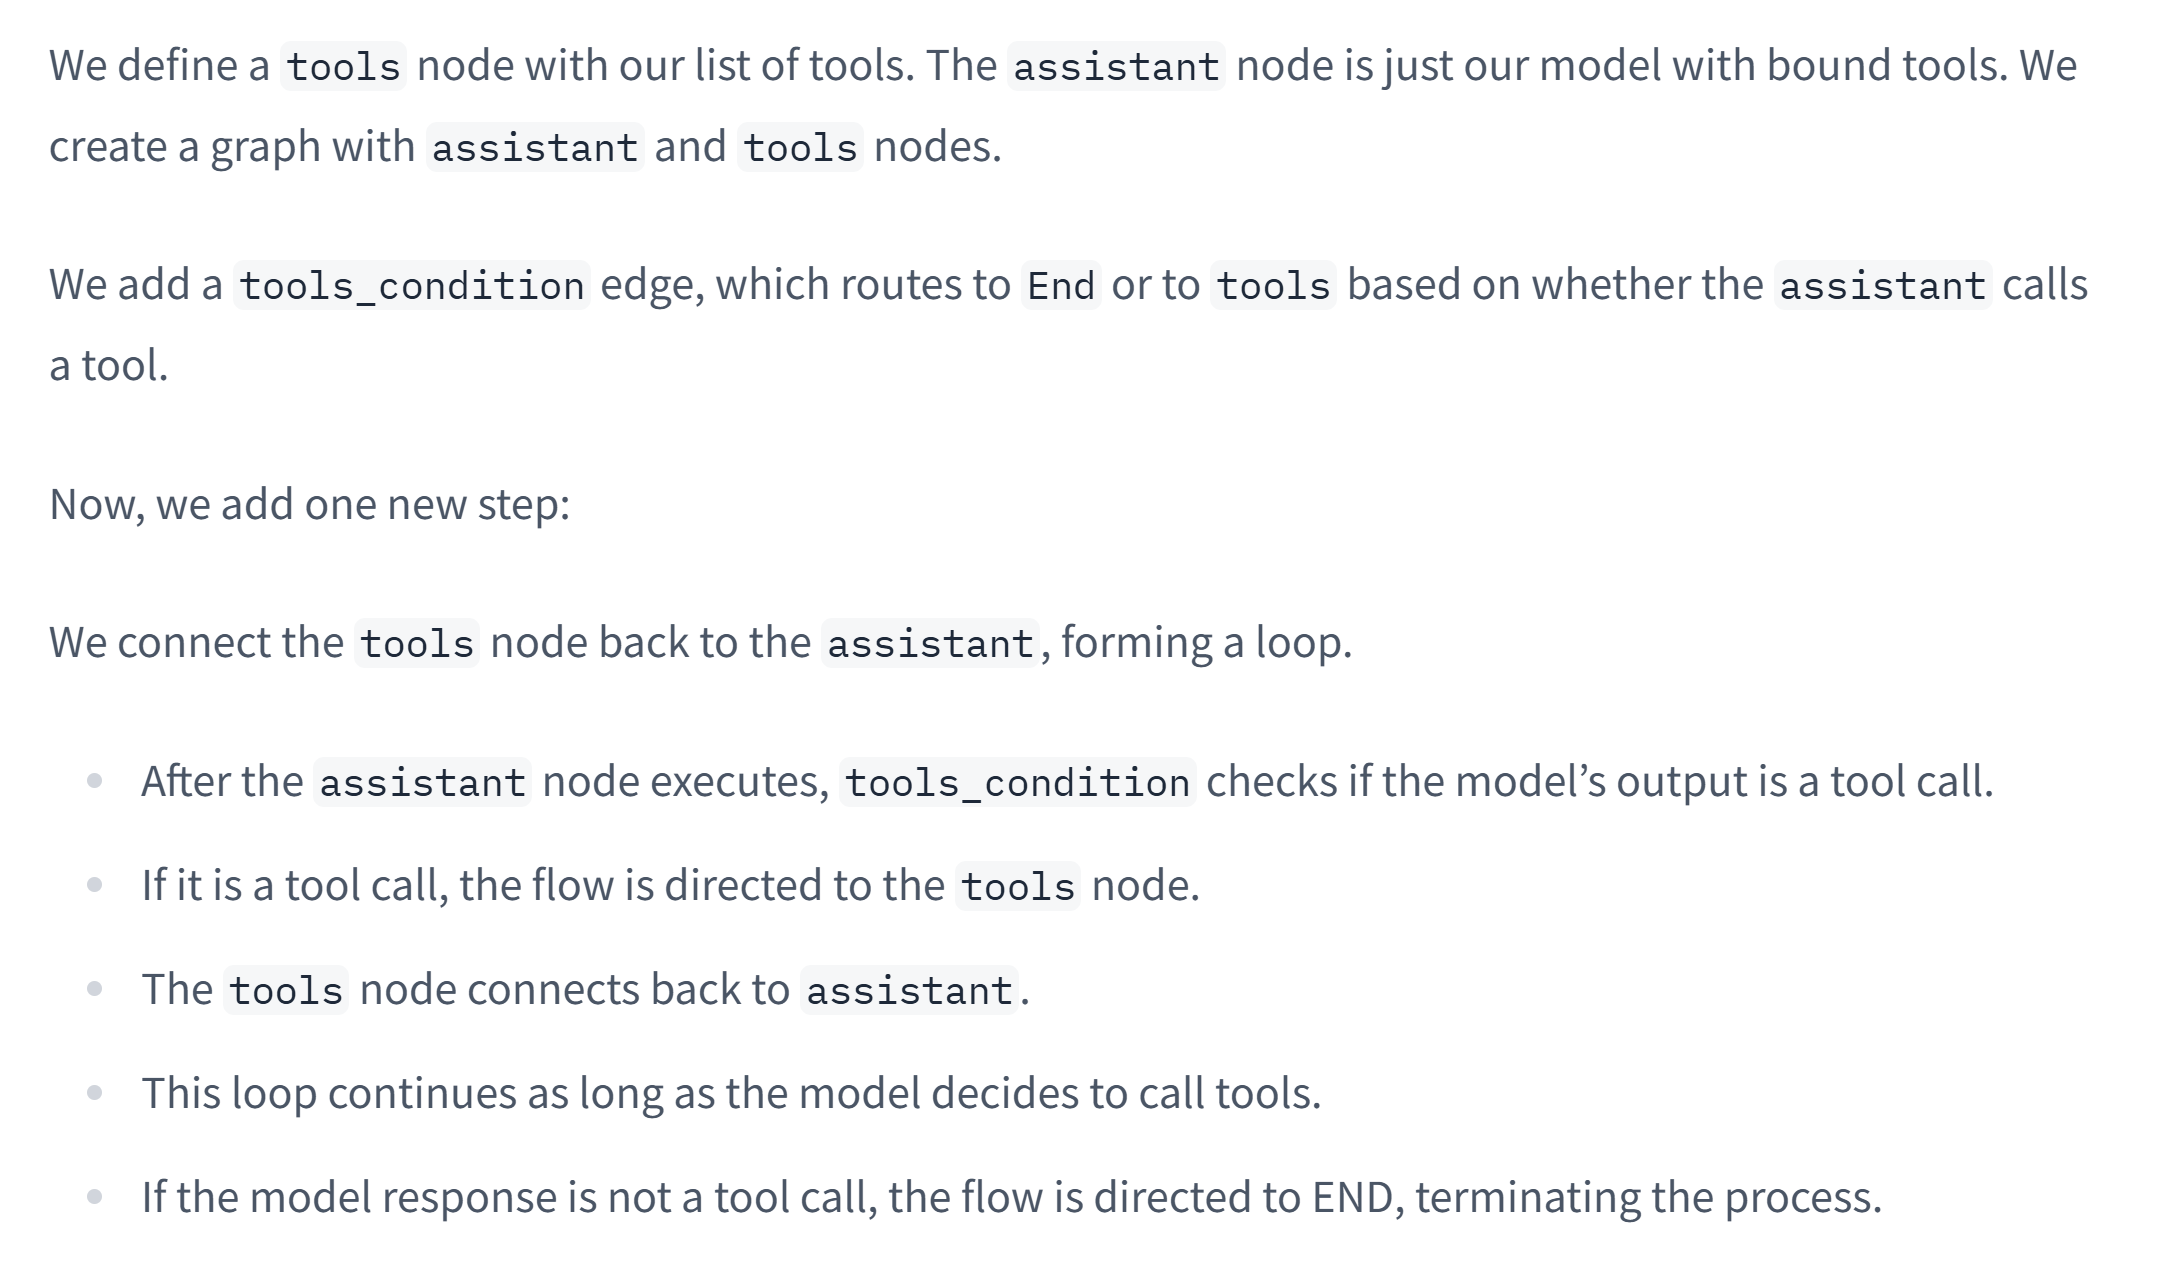

In [31]:
from IPython.display import Image, display
display(Image(filename='img.png', width=400))

In [6]:
# now here the ask will be agent state is This state is a little more complex than the previous ones we have seen. AnyMessage is a class from Langchain that defines messages, and add_messages is an operator that adds the latest message rather than overwriting it with the latest state. 

# because its a react loop we want the previous history to be passed and add_messages does that (because react agent we need to send tool call output back to decide whether we wnat more iterations or not)
#Maintain contextual awareness of previous interactions (ensured by the operator add_messages)

In [10]:
import base64
from typing import List, TypedDict, Annotated, Optional
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

class AgentState(TypedDict):
    input_file: Optional[str]  # Contains file path (PDF/PNG) or any input
    messages: Annotated[list[AnyMessage], add_messages]

#bind few tools to llm
vision_llm = ChatOpenAI(model="gpt-4o", api_key="key-here")
def extract_text(img_path: str) -> str:
    """
    Extract text from an image file using a multimodal model.
    
    Master Wayne often leaves notes with his training regimen or meal plans.
    This allows me to properly analyze the contents.
    """
    all_text = ""
    try:
        # Read image and encode as base64
        with open(img_path, "rb") as image_file:
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        # Prepare the prompt including the base64 image data
        message = [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": (
                            "Extract all the text from this image. "
                            "Return only the extracted text, no explanations."
                        ),
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        },
                    },
                ]
            )
        ]

        # Call the vision-capable model
        response = vision_llm.invoke(message)

        # Append extracted text
        all_text += response.content + "\n\n"

        return all_text.strip()
    except Exception as e:
        # A butler should handle errors gracefully
        error_msg = f"Error extracting text: {str(e)}"
        print(error_msg)
        return ""
def divide(a: int, b: int) -> float:
    """Divide a and b - for Master Wayne's occasional calculations."""
    return a / b

# Equip with tools
tools = [
    divide,
    extract_text
]

llm = ChatOpenAI(model="gpt-4o",api_key="key-here")
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)
#now llm is ready to be use in the assistant node of the graph

#if we dont have function calling/tool binding feature we will have to manually implement the orchestration, basically whats happening rn is the assistant output will be llm response (where the ai message can be the tool call schema which the tool node picks up from ai message)
#if we dont have then then ew need to format the llm output in that manner, parse it, create a langchain aimessage that contains tool_calls else normal response, toolnode will take this

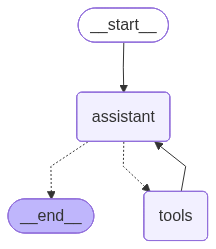

In [5]:
#assistant node
def assistant(state: AgentState):
    # System message
    textual_description_of_tool="""
    extract_text(img_path: str) -> str:
        Extract text from an image file using a multimodal model.

        Args:
            img_path: A local image file path (strings).

        Returns:
            A single string containing the concatenated text extracted from each image.
    divide(a: int, b: int) -> float:
        Divide a and b
    """
    image=state["input_file"]
    sys_msg = SystemMessage(content=f"You are a helpful butler named Alfred that serves Mr. Wayne and Batman. You can analyse documents and run computations with provided tools:\n{textual_description_of_tool} \n You have access to some optional images. Currently the loaded image is: {image}")

    return {
        "messages": [llm_with_tools.invoke([sys_msg] + state["messages"])],
        "input_file": state["input_file"]
    }

#build the graph, tools group doesnt need a function, we can just bundle it directly as seen
#then we add the conditonal edge from assitant to either tools or end
#and then a edge back from tools to assistant
# The graph
builder = StateGraph(AgentState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message requires a tool, route to tools
    # Otherwise, provide a direct response
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show the butler's thought process
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
# 2tools currently - analysze image, do division so we can ask 2 usescases

messages = [HumanMessage(content="According to the note provided by Mr. Wayne in the provided images. What's the list of items I should buy for the dinner menu?")]
messages = react_graph.invoke({"messages": messages, "input_file": "Batman_training_and_meals.png"})

messages = [HumanMessage(content="Divide 6790 by 5")]
messages = react_graph.invoke({"messages": messages, "input_file": None})

# Show the messages
for m in messages['messages']:
    m.pretty_print()

#here if we run the first one it will use the image analysis tool correctly get the response and then give final answer
#if we run 2nd one it will use the division tool (the tool usage and invocation is taken care by the function call and the ToolNode)
#basically we abstracted the process